# Covid data preparation
- Merge data
- Groupby
- Visualization

In [1]:
import pandas as pd
import numpy as np


In [22]:
url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
confirmed = pd.read_csv(url)
confirmed = confirmed.drop(['Lat', 'Long'], axis=1) # Drop columns from df
confirmed.shape

(279, 635)

In [23]:
confirmed[confirmed['Country/Region'] == 'Australia']

,Province/State,Country/Region,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,...,9/6/21,9/7/21,9/8/21,9/9/21,9/10/21,9/11/21,9/12/21,9/13/21,9/14/21,9/15/21,9/16/21,9/17/21,9/18/21,9/19/21,9/20/21,9/21/21,9/22/21,9/23/21,9/24/21,9/25/21,9/26/21,9/27/21,9/28/21,9/29/21,9/30/21,10/1/21,10/2/21,10/3/21,10/4/21,10/5/21,10/6/21,10/7/21,10/8/21,10/9/21,10/10/21,10/11/21,10/12/21,10/13/21,10/14/21,10/15/21
8,Australian Capital Territory,Australia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,528,548,563,587,602,617,630,652,665,680,710,725,742,749,765,782,798,817,849,874,893,906,928,959,1011,1063,1101,1129,1162,1190,1231,1271,1296,1326,1358,1386,1437,1483,1518,1538
9,New South Wales,Australia,0,0,0,0,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...,36267,37724,39108,40616,42219,43436,44674,45782,47007,48341,49611,50919,51986,52922,53898,54919,55962,56988,57983,58931,59709,60561,61420,62353,63212,64014,64668,65279,65876,66456,67024,67669,68246,68712,69205,69552,69993,70391,70781,71099
10,Northern Territory,Australia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,203,203,203,203,203,203,203,203,203,204,204,204,204,206,206,206,208,208,208,208,209,209,210,211,211,212,212,212,212,212,212,213,214,214,215,215,216,222,222,224
11,Queensland,Australia,0,0,0,0,0,0,0,1,3,2,3,2,2,3,3,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,...,1991,1991,1992,1995,2002,2003,2007,2009,2010,2013,2014,2015,2015,2017,2018,2019,2021,2021,2022,2022,2022,2028,2029,2035,2039,2042,2043,2046,2048,2051,2056,2056,2059,2062,2063,2067,2067,2067,2068,2071
12,South Australia,Australia,0,0,0,0,0,0,0,0,0,0,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,...,881,888,889,891,891,892,894,895,896,896,898,898,898,898,898,898,899,900,900,900,901,901,901,901,901,902,904,905,906,907,907,907,908,909,910,913,914,914,914,914
13,Tasmania,Australia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,235,236,236,236,236,236,236,236,236,236,236,236,237,237,237
14,Victoria,Australia,0,0,0,0,1,1,1,1,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,...,23429,23641,23964,24297,24747,25128,25591,26036,26439,26942,27439,27968,28456,29008,29596,30216,30961,31679,32515,33294,33967,34975,35904,37333,38476,39952,41128,42505,44251,45664,47266,49104,51012,52902,54470,55936,57470,59763,61869,63836
15,Western Australia,Australia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1087,1087,1088,1088,1088,1089,1089,1089,1089,1089,1089,1092,1092,1093,1094,1094,1094,1094,1095,1095,1095,1096,1096,1096,1096,1096,1096,1099,1109,1110,1110,1110,1110,1110,1110,1110,1111,1111,1111,1112


In [12]:
# Exercise:
# Identify number of confired cases for India as of "12/31/20"
confirmed[confirmed['Country/Region'] == 'India']['12/31/20'].iloc[0]

10286709

In [17]:
# Identify number of confirmed cases for Australia as of "12/31/20"
confirmed[confirmed['Country/Region'] == 'Australia']['12/31/20'].sum()

28425

## Melting (wide format to long format)

In [29]:
confirmed_long = pd.melt(confirmed, id_vars=['Province/State', 'Country/Region'],
                         var_name='Date', value_name='confirmed')
confirmed_long.head(1)

,Province/State,Country/Region,Date,confirmed
0,NaN,Afghanistan,1/22/20,0


In [28]:
confirmed_long = pd.melt(confirmed, id_vars=['Province/State', 'Country/Region'])
confirmed_long = confirmed_long.rename(columns={'variable': 'Date', 'value': 'confirmed'})
confirmed_long.head()

,Province/State,Country/Region,Date,confirmed
0,NaN,Afghanistan,1/22/20,0
1,NaN,Albania,1/22/20,0
2,NaN,Algeria,1/22/20,0
3,NaN,Andorra,1/22/20,0
4,NaN,Angola,1/22/20,0


In [31]:
confirmed_country = confirmed_long.groupby(['Country/Region', 'Date']).agg(
    confirmed=('confirmed', 'sum')).reset_index()
confirmed_country.head()

,Country/Region,Date,confirmed
0,Afghanistan,1/1/21,52513
1,Afghanistan,1/10/21,53489
2,Afghanistan,1/11/21,53538
3,Afghanistan,1/12/21,53584
4,Afghanistan,1/13/21,53690


In [40]:
url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
confirmed = pd.read_csv(url)
confirmed = confirmed.drop(['Lat', 'Long'], axis=1) # Drop columns from df
confirmed_long = pd.melt(confirmed, id_vars=['Province/State', 'Country/Region'],
                         var_name='Date', value_name='confirmed')
confirmed_country = confirmed_long.groupby(['Country/Region', 'Date']).agg(
    confirmed=('confirmed', 'sum')).reset_index()

### Exercises
1. Convert data type of Date column (object to datetime)
2. Time period of this data: Min and maximum date available in this data
3. Sort the data frame by `Country/Region` and `Date`
4. Filter the data for India and plot a line chart for confirmed cases

2020-01-22 00:00:00 2021-10-15 00:00:00


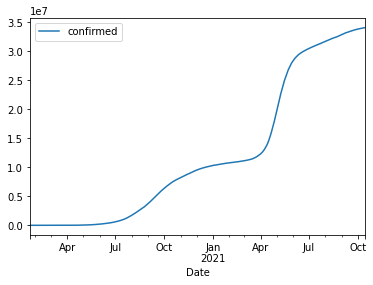

In [61]:
# 1. Convert data type of Date column (object to datetime)
confirmed_country['Date'] = pd.to_datetime(confirmed_country['Date'],
                                           format='%m/%d/%y')

# 2. Time period of this data: Min and maximum date available in this data
print(confirmed_country['Date'].min(), confirmed_country['Date'].max())

# 3. Sort the data frame by Country/Region and Date
confirmed_country = confirmed_country.sort_values(by=['Country/Region', 'Date'])

# 4. Filter the data for India and plot a line chart for confirmed cases
india = confirmed_country[confirmed_country['Country/Region'] == 'India']
india.plot.line(x='Date', y='confirmed');

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


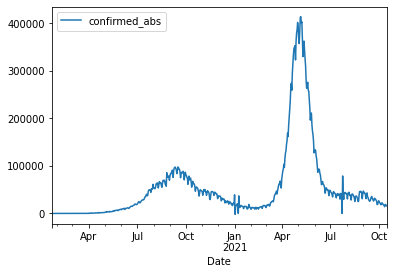

In [68]:
india['confirmed_abs'] = india['confirmed'].diff()
india.plot.line(x='Date', y='confirmed_abs');

### Exercise
- Identify top ten countries based on total number of cases as on yesterday using `confirmed_country` data frame
- Plot the results using bar chart

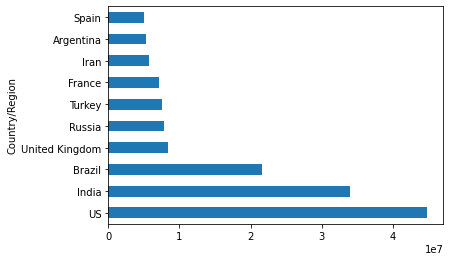

In [82]:
summary = confirmed_country.groupby(['Country/Region']).agg(Total_Cases=('confirmed', 'last'))
summary = summary.sort_values(by='Total_Cases', ascending=False)
summary.head(10)['Total_Cases'].plot.barh();

## Merging

In [ ]:
url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
confirmed = pd.read_csv(url)
confirmed = confirmed.drop(['Lat', 'Long'], axis=1) # Drop columns from df
confirmed_long = pd.melt(confirmed, id_vars=['Province/State', 'Country/Region'],
                         var_name='Date', value_name='confirmed')
confirmed_country = confirmed_long.groupby(['Country/Region', 'Date']).agg(
    confirmed=('confirmed', 'sum')).reset_index()
confirmed_country['Date'] = pd.to_datetime(confirmed_country['Date'],
                                           format='%m/%d/%y')
confirmed_country = confirmed_country.sort_values(by=['Country/Region', 'Date'])

In [90]:
url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv'
deaths = pd.read_csv(url)
deaths = deaths.drop(['Lat', 'Long'], axis=1)
deaths_long = pd.melt(deaths, id_vars=['Province/State', 'Country/Region'],
                         var_name='Date', value_name='deaths')
deaths_country = deaths_long.groupby(['Country/Region', 'Date']).agg(
    deaths=('deaths', 'sum')).reset_index()
deaths_country['Date'] = pd.to_datetime(deaths_country['Date'],
                                           format='%m/%d/%y')
deaths_country = deaths_country.sort_values(by=['Country/Region', 'Date'])

In [91]:
confirmed_country.shape, deaths_country.shape

((123435, 3), (123435, 3))

In [93]:
confirmed_country.head()

,Country/Region,Date,confirmed
14,Afghanistan,2020-01-22,0
16,Afghanistan,2020-01-23,0
18,Afghanistan,2020-01-24,0
20,Afghanistan,2020-01-25,0
22,Afghanistan,2020-01-26,0


In [94]:
deaths_country.head()

,Country/Region,Date,deaths
14,Afghanistan,2020-01-22,0
16,Afghanistan,2020-01-23,0
18,Afghanistan,2020-01-24,0
20,Afghanistan,2020-01-25,0
22,Afghanistan,2020-01-26,0


In [104]:
df1 = pd.DataFrame({
    'product': ['a', 'b', 'c', 'd'],
    'Oct_Sales': [10, 20, 30, 40]
})
df2 = pd.DataFrame({
    'product': ['a', 'b', 'd', 'e'],
    'Nov_Sales': [3, 5, 8, 4]
})

# Inner join
df = pd.merge(left=df1, right=df2, on=['product'], how='inner')
df

,product,Oct_Sales,Nov_Sales
0,a,10,3
1,b,20,5
2,d,40,8


In [98]:
# Left join
df = pd.merge(left=df1, right=df2, on=['product'], how='left')
df

,product,Oct_Sales,Nov_Sales
0,a,10,3.0
1,b,20,5.0
2,c,30,NaN
3,d,40,8.0


In [105]:
# Right join
df = pd.merge(left=df1, right=df2, on=['product'], how='left')
df

,product,Oct_Sales,Nov_Sales
0,a,10,3.0
1,b,20,5.0
2,c,30,NaN
3,d,40,8.0


In [100]:
# Outer join
df = pd.merge(left=df1, right=df2, on=['product'], how='outer')
df

,product,Oct_Sales,Nov_Sales
0,a,10.0,3.0
1,b,20.0,5.0
2,c,30.0,NaN
3,d,40.0,8.0
4,e,NaN,4.0


### Exercise
1. Merge the data frames `confirmed_country` and `deaths_country`

In [106]:
covid_data = pd.merge(left=confirmed_country,
                      right=deaths_country,
                      on=['Country/Region', 'Date'],
                      how='outer')

,Country/Region,Date,confirmed,deaths
0,Afghanistan,2020-01-22,0,0
1,Afghanistan,2020-01-23,0,0
2,Afghanistan,2020-01-24,0,0
3,Afghanistan,2020-01-25,0,0
4,Afghanistan,2020-01-26,0,0


## Joining

In [121]:
df1 = pd.DataFrame({
    'product': ['a', 'b', 'c', 'd'],
    'Oct_Sales': [10, 20, 30, 40]
})
df2 = pd.DataFrame({
    'product': ['a', 'b', 'd', 'e'],
    'Nov_Sales': [3, 5, 8, 4]
})

'''
pd.merge(df1.set_index('product'),
         df2.set_index('product'),
         left_index=True, right_index=True,
         how='outer')
'''

"\npd.merge(df1.set_index('product'),\n         df2.set_index('product'),\n         left_index=True, right_index=True,\n         how='outer')\n"

In [122]:
df = df1.set_index('product').join([
         df2.set_index('product'),
         df3.set_index('product')], how='outer')
df

,Oct_Sales,Nov_Sales,Dec_Sales
a,10.0,3.0,1.0
b,20.0,5.0,15.0
c,30.0,NaN,NaN
d,40.0,8.0,18.0
e,NaN,4.0,34.0


## Missing Value Identification

In [124]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/employees_attrition.csv'
employees = pd.read_csv(url)
summary = employees.pivot_table(index='JobRole',
                                columns='Department',
                                values='MonthlyIncome',
                                aggfunc='mean')
summary

Department,Human Resources,Research & Development,Sales
JobRole,,,
Healthcare Representative,NaN,7528.763359,NaN
Human Resources,4235.750000,NaN,NaN
Laboratory Technician,NaN,3237.169884,NaN
Manager,18088.636364,17130.333333,16986.972973
Manufacturing Director,NaN,7295.137931,NaN
Research Director,NaN,16033.550000,NaN
Research Scientist,NaN,3239.972603,NaN
Sales Executive,NaN,NaN,6924.279141
Sales Representative,NaN,NaN,2626.000000


In [126]:
summary.isna().sum() # Columnwise summation---> Columnwise no. of missing values

Department
Human Resources           7
Research & Development    3
Sales                     6
dtype: int64

In [131]:
columnwise_nulls = confirmed.isna().sum()
nrows = confirmed.shape[0]
columnwise_nulls / nrows * 100 # Columnwise percentage of missing values

Province/State    68.817204
Country/Region     0.000000
1/22/20            0.000000
1/23/20            0.000000
1/24/20            0.000000
                    ...    
10/11/21           0.000000
10/12/21           0.000000
10/13/21           0.000000
10/14/21           0.000000
10/15/21           0.000000
Length: 635, dtype: float64

In [141]:
confirmed.isna().sum().sum()

192

In [137]:
# Create a function to return total number of missing values in a data frame
def calc_total_nulls(df):
  return df.isna().sum().sum()

#print('Total missing values in confirmed data is %d' % calc_total_nulls(confirmed))
calc_total_nulls(confirmed)



192

In [144]:
df = pd.DataFrame({
    'product': ['a', 'b', 'c', 'd'],
    'Oct_Sales': [10, 20, None, 30],
    'Nov_Sales': [None, 30, 40, 50]
})
df

,product,Oct_Sales,Nov_Sales
0,a,10.0,NaN
1,b,20.0,30.0
2,c,NaN,40.0
3,d,30.0,50.0


### Dropping missing rows

In [145]:
df.dropna() # Drop entire row if there is even a single missing value

,product,Oct_Sales,Nov_Sales
1,b,20.0,30.0
3,d,30.0,50.0


In [149]:
df.dropna(subset=['Nov_Sales'])

,product,Oct_Sales,Nov_Sales
1,b,20.0,30.0
2,c,NaN,40.0
3,d,30.0,50.0


In [151]:
### Filtering for rows which has missing values in a specific column
df[df['Nov_Sales'].isna()]

,product,Oct_Sales,Nov_Sales
0,a,10.0,NaN


# Optional Exercises
Using adult dataset, do the following
1. Perform descriptive statistics on columns ['marital-status', 'relationship']
2. Identify columnwise number of unique values
3. Identify percentage of customers who have monthlyIncome '<=50K' using `class` column
4. Create a pivot table to identify relationship wise(rows), occupation wise (columns) number of customers
5. Identify columnwise total number of missing values


In [152]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/adult.csv'
adult = pd.read_csv(url)
adult.shape

(48842, 15)

In [153]:
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country,class
0,2,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States,<=50K
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K
2,2,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States,<=50K
3,3,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States,<=50K
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba,<=50K


In [154]:
pd.__version__

'1.1.5'